In [7]:
import os
import sys
from datetime import datetime as dt
import numpy as np
import pandas as pd
from keras.layers import LSTM
from keras.models import Sequential

# Create a class for all the machine learning data
class msData:
    def __init__(self,data):
        self.lines = data
        self.header = self.lines[0].split(',')
        self.lines = self.lines[1:]
        print(self.header)
        
    def data2nparray(self):
        self.npdata = np.zeros((len(self.lines), len(self.header) - 1))
        for i, line in enumerate(self.lines):
            try:
                values = [float(x) for x in line.split(',')[1:]]
                if values != []:
                    self.npdata[i,:] = values
            except:
                values = [float(x.replace("?","")) for x in line.split(',')[1:]]
                if values != []:
                    self.npdata[i,:] = values
        #np.random.shuffle(self.npdata)
                    
                
    def zscore_normalize(self,samples):
        self.npnormdata = self.npdata.copy()
        self.mean = self.npdata[:samples].mean(axis=0)
        self.npnormdata -= self.mean
        self.std = self.npdata[:samples].std(axis=0)
        self.npnormdata /= self.std
        # avoiding nan in dataset
        self.npnormdata[:,1] = 0.0
        
        
# Generator yielding timeseries samples and their targets
def generator(data, lookback, delay, min_index, max_index, shuffle=False, step=12 , batch_size=32):
    if max_index is None:
        max_index = len(data) - delay - 1
    i = min_index + lookback
    while 1:
        if shuffle:
            rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)
        samples = np.zeros((len(rows), lookback // step, data.shape[-1]))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            samples[j] = data[indices]
            targets[j] = data[rows[j] + delay][4]
        yield samples, targets
        
# Baseline Mean Absolute Error Computing the common-sense baseline MAE
def baseline_mae():
    batch_maes = []
    for step in range(val_steps):
        samples, targets = next(val_gen)
        preds = samples[:, -1, 4]
        mae = np.mean(np.abs(preds - targets))
        batch_maes.append(mae)
    print(np.mean(batch_maes))
    
        

# Loading datasets    
#data = msData('/Users/mikafabricius/Onedrive/AAU spinoff virksomhed/MCS-Engineering/test 5/complete_measurements_with_designations_miffed.csv')
def sortStart(e):
  return e['start']


dir_str = "/Users/mikafabricius/Library/CloudStorage/OneDrive-Personal/AAU spinoff virksomhed/More Data/"
directory = os.fsencode(dir_str)
counter = 1
files = []
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.startswith("complete") & filename.endswith(".csv"):
        path = os.path.join(dir_str, filename)
        tmp = filename.split('_')
        #files.append({"path": path, "start": int(tmp[4]), "end": int(tmp[6])})
        files.append({"path": path, "start": dt.strptime(tmp[4], '%Y%m%d').date(), "end": dt.strptime(tmp[6], '%Y%m%d').date()})
files.sort(key=sortStart)
print(files)

for dict in files:
    path = dict["path"]
    if counter > 1:
        fopen = open(path)
        data_temp = fopen.read()
        lines_temp = data_temp.split('\n')
        lines = lines + lines_temp[1:]
        fopen.close()
        print(len(lines))
        #sys.exit()
    else:
        fopen = open(path)
        data_temp = fopen.read()
        lines = data_temp.split('\n')
        fopen.close()
        counter += 1
        
    
    
data = msData(lines)

# Parsing data into Numpy arrays
data.data2nparray()


# Looking at how much data we currently have
print(len(data.npdata))

'''
Notes:
Sample time = 5 minutes

'''



[{'path': '/Users/mikafabricius/Library/CloudStorage/OneDrive-Personal/AAU spinoff virksomhed/More Data/complete_measurements_with_designations_20240325_000000_20240408_000000.csv', 'start': datetime.date(2024, 3, 25), 'end': datetime.date(2024, 4, 8)}, {'path': '/Users/mikafabricius/Library/CloudStorage/OneDrive-Personal/AAU spinoff virksomhed/More Data/complete_measurements_with_designations_20240408_000000_20240422_000000.csv', 'start': datetime.date(2024, 4, 8), 'end': datetime.date(2024, 4, 22)}, {'path': '/Users/mikafabricius/Library/CloudStorage/OneDrive-Personal/AAU spinoff virksomhed/More Data/complete_measurements_with_designations_20240422_000000_20240506_000000.csv', 'start': datetime.date(2024, 4, 22), 'end': datetime.date(2024, 5, 6)}, {'path': '/Users/mikafabricius/Library/CloudStorage/OneDrive-Personal/AAU spinoff virksomhed/More Data/complete_measurements_with_designations_20240506_000000_20240520_000000.csv', 'start': datetime.date(2024, 5, 6), 'end': datetime.date(20

'\nNotes:\nSample time = 5 minutes\n\n'

[1060.9252  1070.7562  1077.8843  ... 1003.60187  971.778      0.     ]


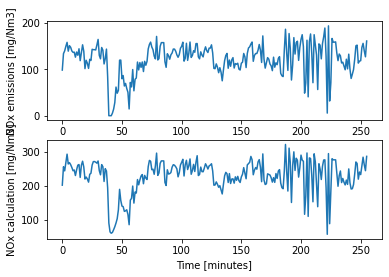

In [11]:
#Plot the first 24 hours of data to see the fluctuation over 24 hours
from matplotlib import pyplot as plt

fig, (ax1,ax2) = plt.subplots(2, 1)

ax1.plot(range(256), data.npdata[:256,4])
ax1.set_ylabel('NOx emissions [mg/Nm3]')
ax1.set_xlabel('Time [minutes]')

ax2.plot(range(256), data.npdata[:256, 3])
ax2.set_ylabel('NOx calculation [mg/Nm3]')
ax2.set_xlabel('Time [minutes]')



In [10]:
# Normalizing the data
data.zscore_normalize(len(data.npdata[:,3]))
# Print the normalizing factors to use for predictions.
print(data.mean)
print(data.std)
# convert the norm and std arrays into dataframes
dfmean = pd.DataFrame(data.mean)
dfstd = pd.DataFrame(data.std)

# save the dataframes as a csv file
dfmean.to_csv("scalar_means.csv")
dfstd.to_csv("scalar_std.csv")
print(data.npnormdata)

[9.55724626e+02 8.21207208e+02 7.74882262e+02 1.97889641e+02
 1.12602211e+02 2.70157385e+02 2.83995535e+00 6.17912193e+00
 9.13450441e+01 1.15518393e+05 1.31636599e+05 6.70836212e+04
 1.05472929e+02 8.40092778e+03 1.27796962e+04]
[2.95867770e+02 3.27398430e+02 2.39708287e+02 7.23804884e+01
 4.31182221e+01 9.62327097e+01 7.39120467e+00 4.97307714e+00
 2.93671018e+01 3.18787606e+04 3.71338049e+04 1.87662180e+04
 3.56001373e+01 3.14171489e+03 3.63631644e+03]


AttributeError: 'DataFrame' object has no attribute 'to_txt'

Text(0.5, 0, 'Time [minutes]')

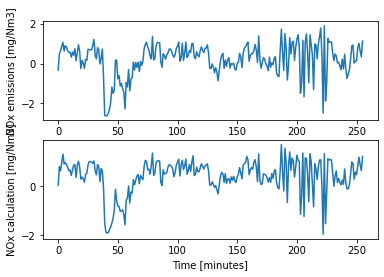

In [4]:
#Plot the first 24 hours of data to see the fluctuation over 24 hours
fig, (ax1,ax2) = plt.subplots(2, 1)

ax1.plot(range(256), data.npnormdata[:256,4])
ax1.set_ylabel('NOx emissions [mg/Nm3]')
ax1.set_xlabel('Time [minutes]')

ax2.plot(range(256), data.npnormdata[:256, 3])
ax2.set_ylabel('NOx calculation [mg/Nm3]')
ax2.set_xlabel('Time [minutes]')


In [17]:
# Preparing the training, validation, and test generators

lookback = 2 # Model input will go back lookback*5 minutes, this will require memory alocation of lookback*5 minutes of data
step = 1 # The period, in timesteps, at which you sample data. 1 = every 5 minutes we sample data.
delay = 1 # Targets will be delay*timesteps into the future
batch_size = 32 # Batch size

train_gen = generator(data.npnormdata, lookback=lookback, delay=delay, min_index=0, max_index=40000, shuffle=True, step=step, batch_size=batch_size)
val_gen = generator(data.npnormdata, lookback=lookback, delay=delay, min_index=40001, max_index=65000, step=step, batch_size=batch_size)
test_gen = generator(data.npnormdata, lookback=lookback, delay=delay, min_index=65001, max_index=None, step=step, batch_size=batch_size)

val_steps = (65000 - 40001 - lookback)
test_steps = (len(data.npnormdata) - 65001 - lookback)

In [18]:
# Baseline performance using MAE
baseline_mae() 
print(0.39 * data.std[4])
print(0.30 * data.std[4])

0.3903522733227103
16.81610660616373
12.935466620125945


In [19]:
# Generic ML approach
from keras import Sequential
from keras import layers
from keras.optimizers import RMSprop
model = Sequential()
print((lookback // step, data.npnormdata.shape[-1]))
model.add(layers.Flatten(input_shape=(lookback // step, data.npnormdata.shape[-1])))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1))
model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(train_gen, steps_per_epoch=100, epochs=10, validation_data=val_gen, validation_steps=val_steps)

Epoch 1/10
 82/100 [=======================>......] - ETA: 0s - loss: 0.4657

KeyboardInterrupt: 

In [15]:
model.save('DenseModel.keras')  # The file needs to end with the .keras extension

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 30)                0         
                                                                 
 dense (Dense)               (None, 1024)              31744     
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dense_3 (Dense)             (None, 128)               32896     
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 32)                2

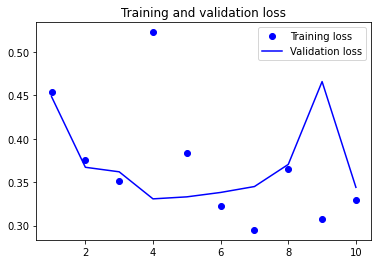

In [8]:
# Plotting the results of the basic approach
model.summary()
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [33]:
# Trying out a recurrent NN, using a GRU-based model

model = Sequential()
#model.add(layers.GRU(64, return_sequences=True))
#model.add(layers.Dense(64, activation='relu'))
model.add(layers.GRU(256, return_sequences=True))
model.add(layers.GRU(256))
#model.add(layers.GRU(256, input_shape=(None, data.npnormdata.shape[-1])))
model.add(layers.Dense(32, activation='relu'))
#model.add(layers.GRU(16))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(train_gen, steps_per_epoch=100, epochs=20, validation_data=val_gen, validation_steps=val_steps)

Epoch 1/20
100/100 [==============================] - 49s 470ms/step - loss: 0.4203 - val_loss: 0.3438
Epoch 2/20
100/100 [==============================] - 75s 755ms/step - loss: 0.3856 - val_loss: 0.3395
Epoch 3/20
 98/100 [============================>.] - ETA: 0s - loss: 0.3622

KeyboardInterrupt: 

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_23 (GRU)                (None, None, 64)          15552     
                                                                 
 dense_70 (Dense)            (None, None, 32)          2080      
                                                                 
 gru_24 (GRU)                (None, 16)                2400      
                                                                 
 dense_71 (Dense)            (None, 8)                 136       
                                                                 
 dense_72 (Dense)            (None, 1)                 9         
                                                                 
Total params: 20,177
Trainable params: 20,177
Non-trainable params: 0
_________________________________________________________________


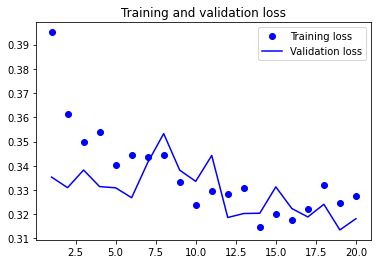

dict_keys(['loss', 'val_loss'])


In [31]:
# Plotting the results

model.summary()
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

print(history.history.keys())


In [1]:
# Applying dropout and recurrent dropout methods for regularization



range(0, 5)


In [34]:
# Training and evaluating an LSTM using reversed sequences

model = Sequential()
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.LSTM(64, input_shape=(None, 64)))
#model.add(layers.GRU(256, input_shape=(None, data.npnormdata.shape[-1])))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(momentum=0.0), loss='mae')
history = model.fit(train_gen, steps_per_epoch=100, epochs=10, validation_data=val_gen, validation_steps=val_steps)

Epoch 1/10
100/100 [==============================] - 29s 277ms/step - loss: 0.4040 - val_loss: 0.3383
Epoch 2/10
100/100 [==============================] - 27s 276ms/step - loss: 0.3678 - val_loss: 0.3317
Epoch 3/10
100/100 [==============================] - 27s 272ms/step - loss: 0.3594 - val_loss: 0.3349
Epoch 4/10
100/100 [==============================] - 26s 267ms/step - loss: 0.3490 - val_loss: 0.3328
Epoch 5/10
100/100 [==============================] - 26s 263ms/step - loss: 0.3410 - val_loss: 0.3261
Epoch 6/10
100/100 [==============================] - 26s 262ms/step - loss: 0.3362 - val_loss: 0.3379
Epoch 7/10
100/100 [==============================] - 26s 266ms/step - loss: 0.3468 - val_loss: 0.3357
Epoch 8/10
100/100 [==============================] - 27s 271ms/step - loss: 0.3299 - val_loss: 0.3283
Epoch 9/10
100/100 [==============================] - 27s 270ms/step - loss: 0.3316 - val_loss: 0.3376
Epoch 10/10
100/100 [==============================] - 27s 273ms/step - l

In [ ]:
model.save('test_model.keras')